<a href="https://colab.research.google.com/github/Sidbewendin/credit-risk-scoring/blob/main/credit_risk_scoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Risk Scoring Project

## Objective
The goal of this project is to build a machine learning model capable of predicting the credit risk of a client (good or bad) based on financial and personal attributes.

## Context
In the financial industry credit risk assessment is crucial to decide whether a loan should be granted. Poor risk evaluation can lead to financial losses.

In [1]:
# Credit Risk Scoring Project
# Author: Sidbewendin Yameogo

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [2]:
!pip install xgboost

## Dataset
We use the German Credit Dataset, which contains information about individuals, including:
- Age
- Job
- Housing situation
- Credit amount
- Duration of the loan
- Purpose of the credit

The target variable is:
- Risk: indicates whether a client is considered good or bad.

In [3]:
# Upload the dataset file from the local computer to Google Colab
from google.colab import files
uploaded = files.upload()

Saving credit_data.csv to credit_data.csv


In [4]:
import pandas as pd

df = pd.read_csv("credit_data.csv")

df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [5]:
df.shape

(1000, 11)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [7]:
# Drop useless index column
df = df.drop(columns=["Unnamed: 0"])

## Approach
The project will follow these steps:
1. Data exploration
2. Data preprocessing
3. Model training and evaluation

##Data exploration

In [8]:
# Check for missing values to identify potential data quality issues
df.isnull().sum()

,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,183
Checking account,394
Credit amount,0
Duration,0
Purpose,0
Risk,0


In [9]:
# Generate summary statistics for numerical variables
df.describe()

,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,1.904000,3271.258000,20.903000
std,11.375469,0.653614,2822.736876,12.058814
min,19.000000,0.000000,250.000000,4.000000
25%,27.000000,2.000000,1365.500000,12.000000
50%,33.000000,2.000000,2319.500000,18.000000
75%,42.000000,2.000000,3972.250000,24.000000
max,75.000000,3.000000,18424.000000,72.000000


In [10]:
# Display all column names to identify the target variable and understand the dataset features
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [11]:
# Count the number of observations for each credit risk class
df["Risk"].value_counts()

,count
Risk,
good,700
bad,300


### Target Distribution

The dataset contains:
- 700 good clients (70%)
- 300 bad clients (30%)

This indicates a class imbalance, where good clients are more frequent than bad clients.
This imbalance must be considered when evaluating machine learning models, especially in a financial context where detecting risky clients is critical.

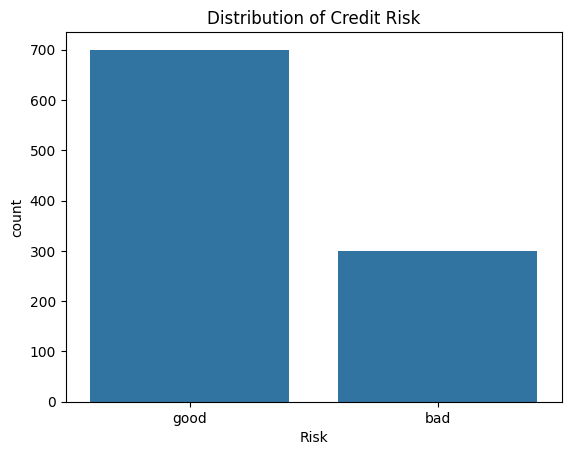

In [12]:
# Visualize the distribution of the target variable
sns.countplot(x="Risk", data=df)
plt.title("Distribution of Credit Risk")
plt.show()

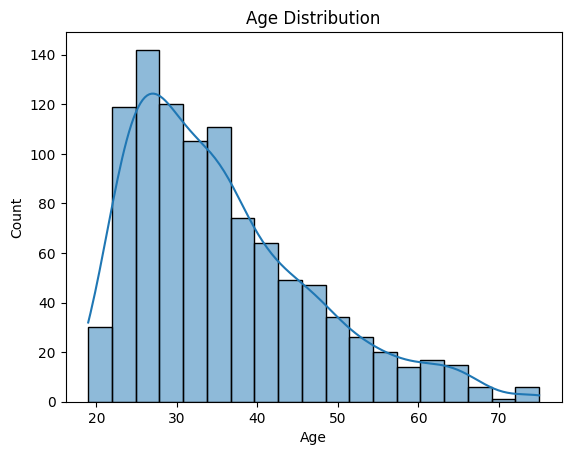

In [13]:
# Plot the distribution of client age
sns.histplot(df["Age"], kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

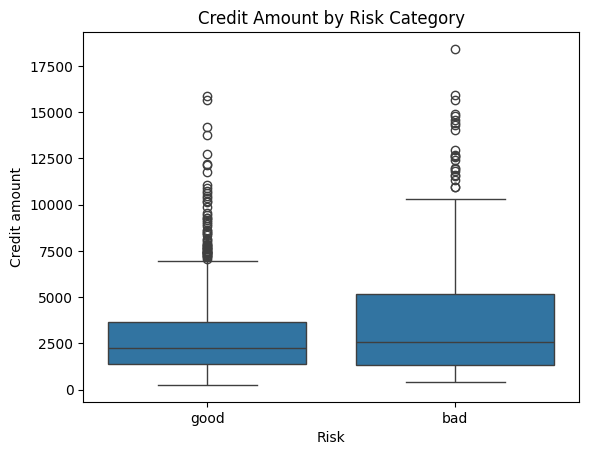

In [14]:
# Compare credit amount across risk categories
sns.boxplot(x="Risk", y="Credit amount", data=df)
plt.title("Credit Amount by Risk Category")
plt.xlabel("Risk")
plt.ylabel("Credit amount")
plt.show()

### Credit Amount vs Risk

The boxplot shows that clients with higher credit amounts tend to have a higher risk.

Bad clients generally request larger credit amounts and show more variability compared to good clients.

This suggests that credit amount may be an important feature for predicting credit risk.

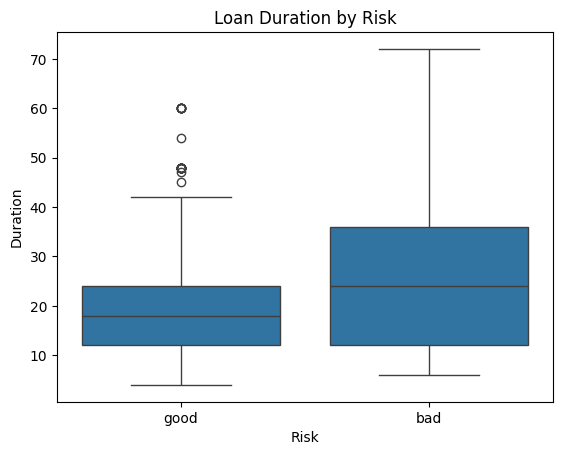

In [15]:
# Compare loan duration across risk categories
sns.boxplot(x="Risk", y="Duration", data=df)
plt.title("Loan Duration by Risk")
plt.xlabel("Risk")
plt.ylabel("Duration")
plt.show()

###Clients with longer loan durations tend to have a higher risk.

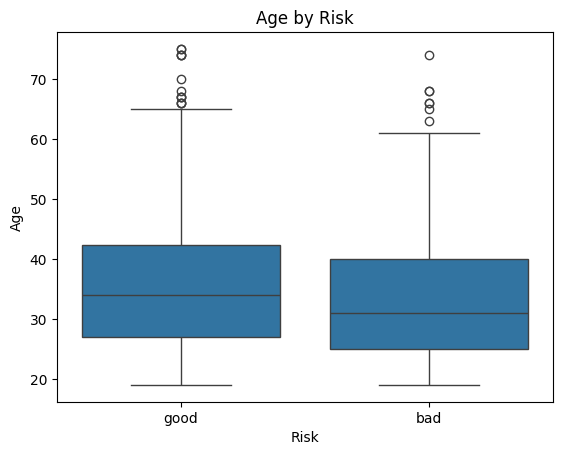

In [16]:
# Compare age across risk categories
sns.boxplot(x="Risk", y="Age", data=df)
plt.title("Age by Risk")
plt.xlabel("Risk")
plt.ylabel("Age")
plt.show()

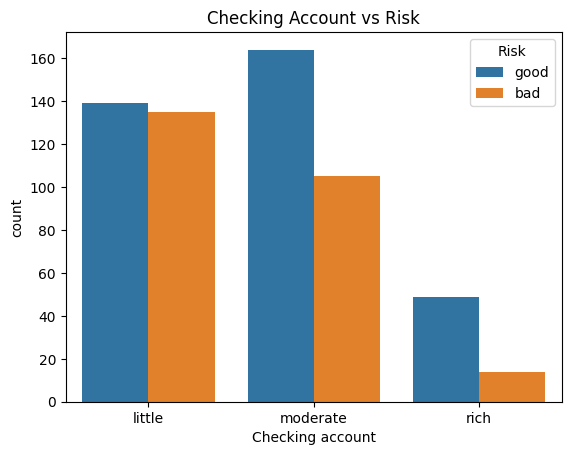

In [17]:
# Compare checking account status across risk
sns.countplot(x="Checking account", hue="Risk", data=df)
plt.title("Checking Account vs Risk")
plt.show()

### Checking Account vs Risk

The analysis shows a clear relationship between checking account status and credit risk.

Clients with low account balances ("little") tend to have higher risk, while clients with higher balances ("rich") are much less likely to be risky.

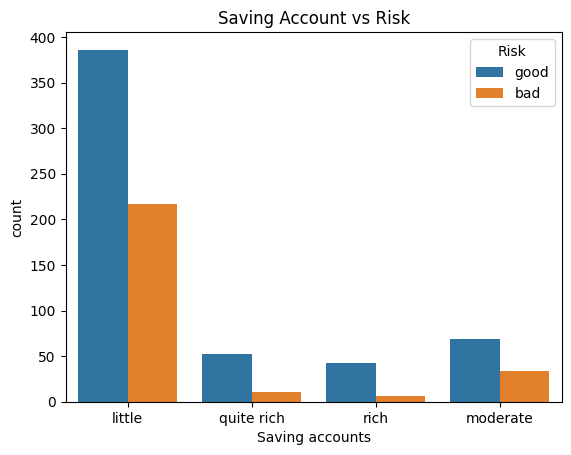

In [18]:
# Compare saving account status across risk
sns.countplot(x="Saving accounts", hue="Risk", data=df)
plt.title("Saving Account vs Risk")
plt.show()

### Saving Account vs Risk

The analysis shows that clients with low savings ("little") tend to have higher risk. Clients with higher savings ("rich" or "quite rich") are significantly less likely to be risky. Saving account status is an important predictor of credit risk.

###The exploratory analysis highlights several important factors influencing credit risk:

- Loan duration is strongly associated with higher risk.
- Clients with lower checking account balances tend to be more risky.
- Saving account status is also a strong indicator of financial stability.
- Credit amount shows some relationship with risk.
- Age appears to have a weaker impact.

These insights will guide the feature engineering and modeling steps.

##DATA PREPROCESSING

In [19]:
df = df.drop(columns=df.columns[0])
df.head()

,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,male,2,own,NaN,little,1169,6,radio/TV,good
1,female,2,own,little,moderate,5951,48,radio/TV,bad
2,male,1,own,little,NaN,2096,12,education,good
3,male,2,free,little,little,7882,42,furniture/equipment,good
4,male,2,free,little,little,4870,24,car,bad


In [20]:
# Drop column only if it exists
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

In [21]:
# Fill missing values in categorical columns with "unknown"
df["Saving accounts"] = df["Saving accounts"].fillna("unknown")
df["Checking account"] = df["Checking account"].fillna("unknown")

In [22]:
# Convert the target variable into numerical format
# good -> 0, bad -> 1
df["Risk"] = df["Risk"].map({"good": 0, "bad": 1})

In [23]:
# Separate features (X) and target (y)
X = df.drop("Risk", axis=1)
y = df["Risk"]

In [24]:
# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)

Categorical: ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']
Numerical: ['Job', 'Credit amount', 'Duration']


In [25]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Preprocess numerical columns: impute missing values then scale
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [26]:
from sklearn.preprocessing import OneHotEncoder

# Preprocess categorical columns: impute missing values then encode
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [27]:
from sklearn.compose import ColumnTransformer

# Apply different preprocessing to numerical and categorical columns
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])

In [28]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(800, 8)
(200, 8)
(800,)
(200,)


#Model training

In [30]:
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(class_weight="balanced", max_iter=1000))
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Job', 'Credit amount',
                                                   'Duration']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex', 'Housing',
                                                   'Saving accounts',
                                                   'Checking account',
                                                   'Purpose'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [31]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification report:")
print(classification_report(y_test, y_pred))

print("\nROC-AUC:", roc_auc_score(y_test, y_proba))

Accuracy: 0.725

Confusion matrix:
[[100  41]
 [ 14  45]]

Classification report:
              precision    recall  f1-score   support

           0       0.88      0.71      0.78       141
           1       0.52      0.76      0.62        59

    accuracy                           0.72       200
   macro avg       0.70      0.74      0.70       200
weighted avg       0.77      0.72      0.74       200


ROC-AUC: 0.7943262411347518


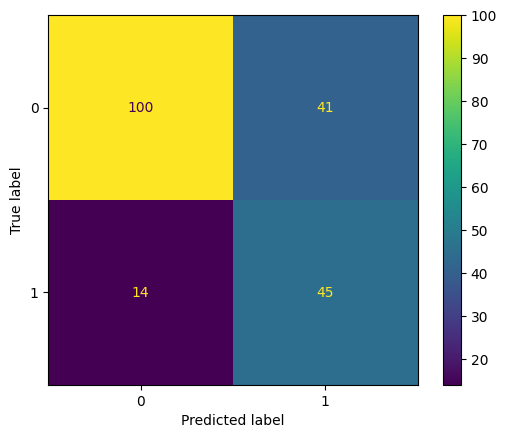

In [32]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()


In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        class_weight="balanced"
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("\nConfusion matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification report:")
print(classification_report(y_test, rf_pred))

print("\nROC-AUC:", roc_auc_score(y_test, rf_proba))

Accuracy: 0.74

Confusion matrix:
[[121  20]
 [ 32  27]]

Classification report:
              precision    recall  f1-score   support

           0       0.79      0.86      0.82       141
           1       0.57      0.46      0.51        59

    accuracy                           0.74       200
   macro avg       0.68      0.66      0.67       200
weighted avg       0.73      0.74      0.73       200


ROC-AUC: 0.7636735184517369


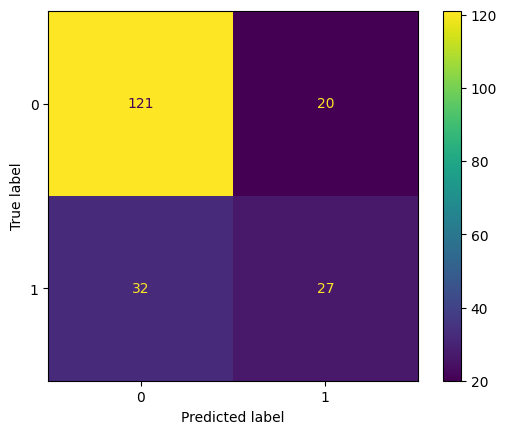

In [34]:
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred)
plt.show()

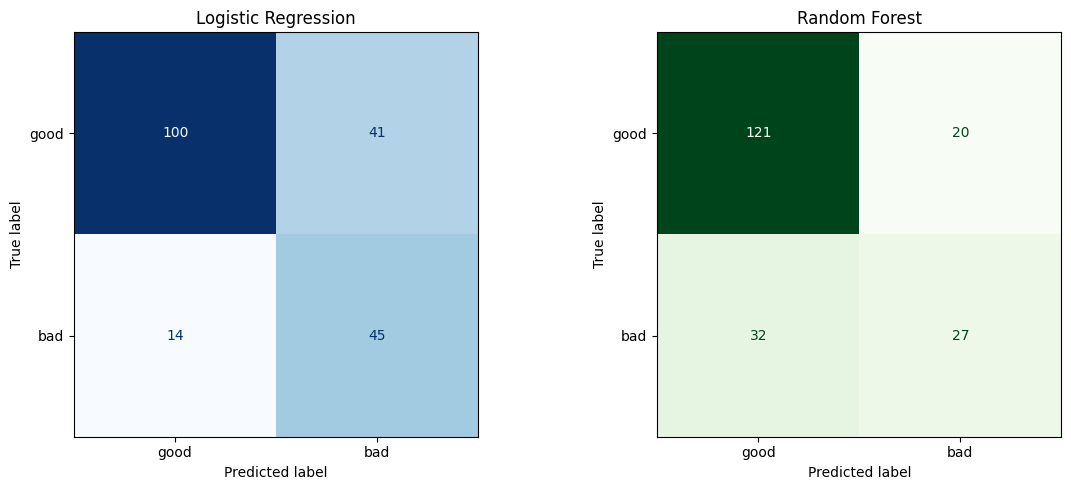

In [35]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["good", "bad"],
    ax=axes[0],
    cmap="Blues",
    colorbar=False
)
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay.from_predictions(
    y_test, rf_pred,
    display_labels=["good", "bad"],
    ax=axes[1],
    cmap="Greens",
    colorbar=False
)
axes[1].set_title("Random Forest")

plt.tight_layout()
plt.show()


### Conclusion
La régression logistique est retenue comme modèle principal.
Même si Random Forest a une accuracy légèrement supérieure, la régression logistique détecte mieux les clients à risque (`bad`) et obtient un meilleur ROC-AUC.

In [36]:
import joblib

joblib.dump(model, "credit_risk_model.joblib")

['credit_risk_model.joblib']

In [37]:
import os
os.listdir()

['.config', 'credit_data.csv', 'credit_risk_model.joblib', 'sample_data']

In [38]:
loaded_model = joblib.load("credit_risk_model.joblib")

In [39]:
sample_client = X_test.iloc[[0]]
loaded_model.predict(sample_client), loaded_model.predict_proba(sample_client)

(array([1]), array([[0.35250497, 0.64749503]]))

In [40]:
import joblib
joblib.dump(model, "credit_risk_model.joblib")

['credit_risk_model.joblib']

In [41]:
from google.colab import files
files.download("credit_risk_model.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [42]:
!pip install fastapi uvicorn pyngrok nest-asyncio

In [43]:
import joblib
import pandas as pd

model = joblib.load("credit_risk_model.joblib")

In [44]:
sample_input = pd.DataFrame([{
    "Age": 35,
    "Sex": "male",
    "Job": 2,
    "Housing": "own",
    "Saving accounts": "little",
    "Checking account": "moderate",
    "Credit amount": 3500,
    "Duration": 24,
    "Purpose": "car"
}])

pred = model.predict(sample_input)[0]
proba = model.predict_proba(sample_input)[0][1]

print("Prediction:", pred)
print("Probability of bad:", proba)

Prediction: 1
Probability of bad: 0.5694675165027754


In [45]:
sample_input = pd.DataFrame([{
    "Age": 30,
    "Sex": "male",
    "Job": 2,
    "Housing": "own",
    "Saving accounts": "rich",
    "Checking account": "moderate",
    "Credit amount": 5500,
    "Duration": 24,
    "Purpose": "car"
}])

pred = model.predict(sample_input)[0]
proba = model.predict_proba(sample_input)[0][1]

print("Prediction:", pred)
print("Probability of bad:", proba)

Prediction: 0
Probability of bad: 0.37577826259999875


In [46]:
!pip install fastapi uvicorn nest-asyncio pyngrok

In [47]:
import joblib
import pandas as pd
from fastapi import FastAPI
from pydantic import BaseModel

In [48]:
model = joblib.load("credit_risk_model.joblib")

In [49]:
app = FastAPI(title="Credit Risk API")

In [50]:
class CreditInput(BaseModel):
    Age: int
    Sex: str
    Job: int
    Housing: str
    Saving_accounts: str
    Checking_account: str
    Credit_amount: float
    Duration: int
    Purpose: str

In [51]:
@app.get("/")
def home():
    return {"message": "Credit Risk API is running"}

In [52]:
@app.post("/predict")
def predict(data: CreditInput):
    input_df = pd.DataFrame([{
        "Age": data.Age,
        "Sex": data.Sex,
        "Job": data.Job,
        "Housing": data.Housing,
        "Saving accounts": data.Saving_accounts,
        "Checking account": data.Checking_account,
        "Credit amount": data.Credit_amount,
        "Duration": data.Duration,
        "Purpose": data.Purpose
    }])

    pred = model.predict(input_df)[0]
    proba = model.predict_proba(input_df)[0][1]
    label = "bad" if pred == 1 else "good"

    return {
        "prediction": label,
        "probability_of_bad": float(round(proba, 4))
    }

In [55]:
import nest_asyncio
import uvicorn

nest_asyncio.apply()